(2, 7) (7, 7) (7, 1)
(20, 7) (20, 7) (20, 1)
20


C:\Users\panda\AppData\Local\Temp\ipykernel_25140\345034480.py:178: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


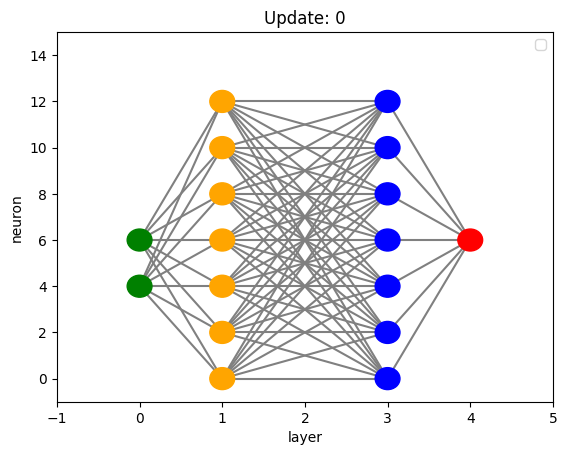

In [22]:
import numpy as np
import pandas as pd
from typing import Tuple
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn import datasets
from sklearn.model_selection import train_test_split
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Ellipse

# read_data, get_df_shape, data_split are the same as HW3
def read_data(filename: str) -> pd.DataFrame:
    d = pd.read_csv(filename)
    df = pd.DataFrame(data=d)
    return df

def extract_features_label(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    # Filter the dataframe to include only Setosa and Virginica rows
    
    # (###NET1 & NET2### i)
    # filtered_df = df[df['variety'].isin(['Versicolor', 'Virginica'])]
    # features = filtered_df[['sepal.length', 'sepal.width']] # accuracy .54
    # labels = filtered_df['variety'].map({'Versicolor': 0, 'Virginica': 1})
    
    # Extract the required features and labels from the filtered dataframe
    
    # (###NET1 & NET2### ii)
    filtered_df = df[df['variety'].isin(['Setosa', 'Virginica'])]
    features = filtered_df[['petal.length', 'petal.width']] # accuracy 1.0
    labels = filtered_df['variety'].map({'Setosa': 0, 'Virginica': 1})
    
    # (tests I ran for NET1)
    #features = filtered_df[['sepal.length', 'petal.width']] # accuracy 1.0
    #features = filtered_df[['petal.length', 'sepal.width']] # accuracy 1.0
    
    # (###NET4### four features i) 
    #filtered_df = df[df['variety'].isin(['Versicolor', 'Virginica'])]
    #features = filtered_df[['sepal.length', 'sepal.width','petal.length', 'petal.width']] # accuracy .54
    #labels = filtered_df['variety'].map({'Versicolor': 0, 'Virginica': 1})
    
    # (###NET4### four features ii)
    #filtered_df = df[df['variety'].isin(['Setosa', 'Virginica'])]
    #features = filtered_df[['sepal.length', 'sepal.width','petal.length', 'petal.width']] # accuracy 1.0
    #labels = filtered_df['variety'].map({'Setosa': 0, 'Virginica': 1})

    return features, labels

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def function_derivative(z):
    fd = sigmoid(z)
    return fd * (1 - fd)


class NN:
    def __init__(self, features,hidden_layers, hidden_neurons, output_neurons, learning_rate):
        self.features = features
        self.hidden_neurons = hidden_neurons
        self.hidden_neurons_2 = hidden_neurons
        self.output_neurons = output_neurons
        self.learning_rate = learning_rate
        self.active = []
        # initialize weights
        self.V = np.random.randn(self.features, self.hidden_neurons)
        self.E = np.random.randn(self.hidden_neurons,self.hidden_neurons_2)
        self.W = np.random.randn(self.hidden_neurons, self.output_neurons)
        print(self.V.shape, self.E.shape, self.W.shape)
        # initialize biases: 0
        self.V0 = np.zeros((self.hidden_neurons))
        self.E0 = np.zeros((self.hidden_neurons_2))
        self.W0 = np.zeros((self.output_neurons))
        #print (self.V,self.E,self.W)
    def train(self, X, t, epochs=1000):
        costs = []
        self.weight_changes = []
        
        for epoch in range(epochs):
            # forward pass
            net_u = X.dot(self.V) + self.V0
            H = sigmoid(net_u)
            net_e = H.dot(self.E) + self.E0
            H2 = sigmoid(net_e)
            net_z = H.dot(self.W) + self.W0
            O = sigmoid(net_z)
            # backpropagation pass
            error_output = O - t
          
            d_W = H2.T.dot(error_output * function_derivative(net_z))
            d_W0 = np.sum(error_output * function_derivative(net_z), axis=0)
           
            error_hidden_layer_2 = error_output.dot(self.W.T) * function_derivative(net_e)
            d_E = H.T.dot(error_hidden_layer_2)
            d_E0 = np.sum(error_hidden_layer_2,axis=0)

            error_hidden_layer = error_hidden_layer_2.dot(self.E.T) * function_derivative(net_u)
            
            d_V = X.T.dot(error_hidden_layer)
            d_V0 = np.sum(error_hidden_layer, axis=0)

            d_V = d_V.values if isinstance(d_V, pd.DataFrame) else d_V
            d_E = d_E.values if isinstance(d_E, pd.DataFrame) else d_E
            d_W = d_W.values if isinstance(d_W, pd.DataFrame) else d_W
            self.weight_changes.append((d_V, d_E, d_W))
            # update weights and biases
            self.W -= self.learning_rate * d_W
            self.W0 -= self.learning_rate * d_W0
            self.E -= self.learning_rate * d_E
            self.E0 -= self.learning_rate * d_E0
            self.V -= self.learning_rate * d_V
            self.V0 -= self.learning_rate * d_V0
            
            #find the cost function
            if epoch % 10 == 0:
                loss =  np.square(np.subtract(t,O)).mean() 
                costs.append(loss)
                
        return costs
    
    def predict(self, X):
        net_u = X.dot(self.V) + self.V0
        H = sigmoid(net_u)
        net_e = H.dot(self.E) + self.E0
        H2 = sigmoid(net_e)
        net_z = H2.dot(self.W) + self.W0
        O = sigmoid(net_z)
        print(H.shape, H2.shape, O.shape)
        print(len(H))
        for i in range(len(H)):
            X = X.values if isinstance(X, pd.DataFrame) else X
            H = H.values if isinstance(H, pd.DataFrame) else H
            H2 = H2.values if isinstance(H2, pd.DataFrame) else H2
            O = O.values if isinstance(O, pd.DataFrame) else O
            self.active.append((X[i], H[i], H2[i], O[i]))
     
        return (O > 0.5).astype(int)
    
def animate_training(weight_changes, active):
    fig, ax = plt.subplots()
    
    num_inputs = 2
    num_hidden = 7
    num_out = 1

    input_nodes = [Ellipse((0, i * 2 + 4), width=0.3, height=0.95, color='green') for i in range(num_inputs)]
    hidden1_nodes = [Ellipse((1, i * 2), width=0.3, height=0.95, color='orange') for i in range(num_hidden)]
    hidden2_nodes = [Ellipse((3, i * 2), width=0.3, height=0.95, color='blue') for i in range(num_hidden)]
    out_nodes = [Ellipse((4, 6), width=0.3, height=0.95, color='red')]

    lines = []
    connections = []
    for i in range(num_inputs):
        for j in range(num_hidden):
            connections.append((input_nodes[i], hidden1_nodes[j]))
            line, = ax.plot([input_nodes[i].center[0], hidden1_nodes[j].center[0]], [input_nodes[i].center[1], hidden1_nodes[j].center[1]], color='grey', zorder=1)
            lines.append(line)
    
    for i in range(num_hidden):
        for j in range(num_hidden):
            connections.append((hidden1_nodes[i], hidden2_nodes[j]))
            line, = ax.plot([hidden1_nodes[i].center[0], hidden2_nodes[j].center[0]], [hidden1_nodes[i].center[1], hidden2_nodes[j].center[1]], color='grey', zorder=1)
            lines.append(line)
    
    for i in range(num_hidden):
        for j in range(num_out):
            connections.append((hidden2_nodes[i], out_nodes[j]))
            line, = ax.plot([hidden2_nodes[i].center[0], out_nodes[j].center[0]], [hidden2_nodes[i].center[1], out_nodes[j].center[1]], color='grey', zorder=1)
            lines.append(line)

    for node in input_nodes + hidden1_nodes + hidden2_nodes + out_nodes:
        node.set_zorder(5)
        ax.add_artist(node)

    ax.set_xlim(-1,5)
    ax.set_ylim(-1,15)
    ax.set_xlabel('layer')
    ax.set_ylabel('neuron')
    ax.legend()
    frames = list(range(0, len(weight_changes), 10))
    title = ax.set_title("Update: 0")
    # def update(epoch):
    #     V, E, W = weight_changes[epoch]

    #     idk = 0
    #     for i in range(num_inputs):
    #         for j in range(num_hidden):
    #             if np.abs(V[i][j]) > 0.03:
    #                 if V[i][j] > 0:
    #                     lines[idk].set_color('green')
    #                 else:
    #                     lines[idk].set_color('red')
    #             else:
    #                 lines[idk].set_color('grey')
    #             idk += 1

    #     for i in range(num_hidden):
    #         for j in range(num_hidden):
    #             if np.abs(E[i][j]) > 0.03:
    #                 if E[i][j] > 0:
    #                     lines[idk].set_color('green')
    #                 else:
    #                     lines[idk].set_color('red')
    #             else:
    #                 lines[idk].set_color('grey')
    #             idk += 1

    #     for i in range(num_hidden):
    #         for j in range(num_out):
    #             if np.abs(W[i][j]) > 0.03:
    #                 if W[i][j] > 0:
    #                     lines[idk].set_color('green')
    #                 else:
    #                     lines[idk].set_color('red')
    #             else:
    #                 lines[idk].set_color('grey')
    #             idk += 1
        
    #     title.set_text(f"Update: {epoch}")

    #     return lines,

    def update(epoch):
        X, H, H2, O = active[epoch]
        for i in range(len(X)):
            if X[i] > 0.5:
                input_nodes[i].set_facecolor('green')
            else:
                input_nodes[i].set_facecolor('grey')
        
        for i in range(len(H)):
            if H[i] > 0.5:
                hidden1_nodes[i].set_facecolor('orange')
            else:
                hidden1_nodes[i].set_facecolor('grey')
        
        for i in range(len(H2)):
            if H2[i] > 0.5:
                hidden2_nodes[i].set_facecolor('blue')
            else:
                hidden2_nodes[i].set_facecolor('grey')
        
        if O > 0.5:
            out_nodes[0].set_facecolor('red')
        else:
            out_nodes[0].set_facecolor('grey')

        for ln, (nA, nB) in zip(lines, connections):
            activeA = nA.get_facecolor() != mpl.colors.to_rgba('grey')
            activeB = nB.get_facecolor() != mpl.colors.to_rgba('grey')
            if activeA and activeB:
                ln.set_color('purple')
            else:
                ln.set_color('grey')
        title.set_text(f"Update: {epoch + 1}")
        return
    ani = FuncAnimation(fig, update, frames=len(active), interval=500, repeat=False)
    plt.show()
    return ani

if __name__ == "__main__":
    def accuracy(t, y_pred):
        accuracy = np.sum(t == y_pred) / len(t)
        return accuracy

    # Read the data
    train_df = read_data("./iris_training_data.csv")
    test_df = read_data("./iris_testing_data.csv")
    
    X, t =  extract_features_label(train_df)
    X_test, t_test = extract_features_label(test_df)

    t = t.values.reshape([len(t),1])
    t_test = t_test.values.reshape([len(t_test),1])
    
nn = NN(features=2,hidden_layers=2, hidden_neurons=7, output_neurons=1, learning_rate=0.01)



# train the network
cost = nn.train(X, t)

# make predictions on the test data
y_pred = nn.predict(X_test)

# evaluate the accuracy
acc = accuracy(t_test,y_pred)
#print('accuracy',acc,'cost',cost)#
  
ani = animate_training(nn.weight_changes, nn.active)
ani.save('testing.gif', writer='pillow', fps=3)
#plt.plot(cost)
#plt.show()
